## 1. EXPLORATORY DATA ANALYSIS (EDA)

IMPORT & LOAD DATA

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/Depresi.csv")

df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33,Visakhapatnam,Student,5,0,8.97,2,0,5-6 hours,Healthy,B.Pharm,Yes,3,1.0,No,1.0
1,8,Female,24,Bangalore,Student,2,0,5.90,5,0,5-6 hours,Moderate,BSc,No,3,2.0,Yes,0.0
2,26,Male,31,Srinagar,Student,3,0,7.03,5,0,Less than 5 hours,Healthy,BA,No,9,1.0,Yes,0.0
3,30,Female,28,Varanasi,Student,3,0,5.59,2,0,7-8 hours,Moderate,BCA,Yes,4,5.0,Yes,1.0
4,32,Female,25,Jaipur,Student,4,0,8.13,3,0,5-6 hours,Moderate,M.Tech,Yes,1,1.0,No,0.0


CEK STRUKTUR DATA

In [3]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28008 entries, 0 to 28007
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     28008 non-null  int64  
 1   Gender                                 28008 non-null  object 
 2   Age                                    28008 non-null  int64  
 3   City                                   28008 non-null  object 
 4   Profession                             28008 non-null  object 
 5   Academic Pressure                      28008 non-null  int64  
 6   Work Pressure                          28008 non-null  int64  
 7   CGPA                                   28008 non-null  float64
 8   Study Satisfaction                     28008 non-null  int64  
 9   Job Satisfaction                       28008 non-null  int64  
 10  Sleep Duration                         28008 non-null  object 
 11  Di

,id,Age,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Work/Study Hours,Financial Stress,Depression
count,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,28008.000000,27963.000000,27966.000000
mean,70613.609933,25.824264,3.141245,0.000428,7.655372,2.944337,0.000678,7.154456,3.139077,0.585354
std,40792.430225,4.903456,1.380940,0.043908,1.470506,1.361318,0.044310,3.708348,1.437839,0.492670
min,2.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,35075.500000,21.000000,2.000000,0.000000,6.287500,2.000000,0.000000,4.000000,2.000000,0.000000
50%,70855.000000,25.000000,3.000000,0.000000,7.770000,3.000000,0.000000,8.000000,3.000000,1.000000
75%,106075.750000,30.000000,4.000000,0.000000,8.920000,4.000000,0.000000,10.000000,4.000000,1.000000
max,141248.000000,59.000000,5.000000,5.000000,10.000000,5.000000,4.000000,12.000000,5.000000,1.000000


CEK MISSING VALUE

id                                        0
Gender                                    0
Age                                       0
City                                      0
Profession                                0
Academic Pressure                         0
Work Pressure                             0
CGPA                                      0
Study Satisfaction                        0
Job Satisfaction                          0
Sleep Duration                            0
Dietary Habits                            0
Degree                                    0
Have you ever had suicidal thoughts ?     0
Work/Study Hours                          0
Financial Stress                         45
Family History of Mental Illness         42
Depression                               42
dtype: int64


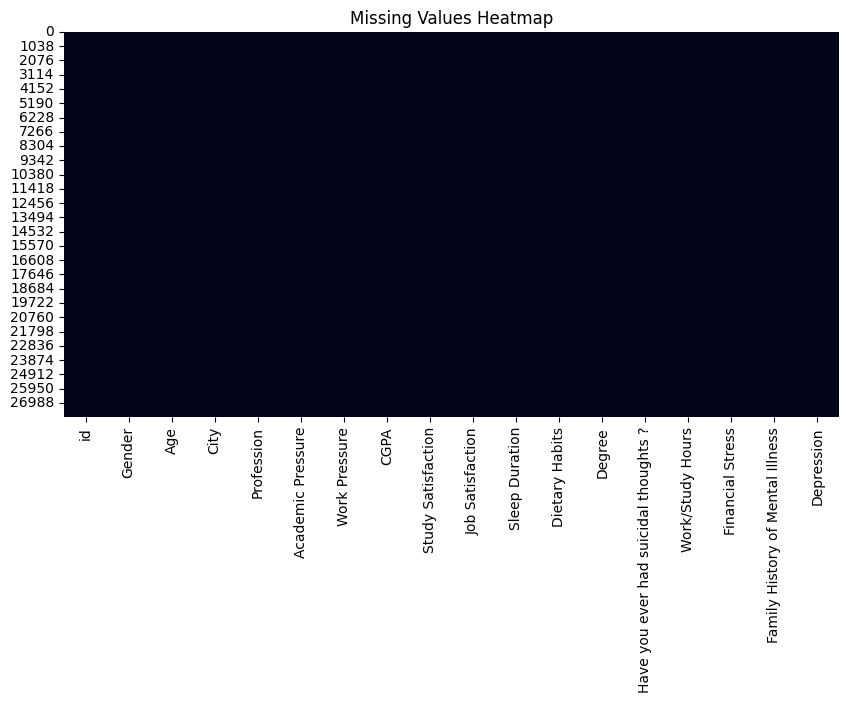

In [4]:
print(df.isnull().sum())

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

In [5]:
print("Duplicate:", df.duplicated().sum())
df = df.drop_duplicates()

Duplicate: 46


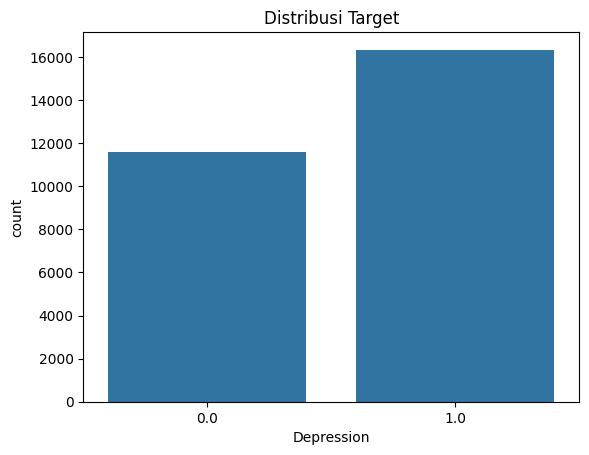

In [6]:
sns.countplot(x='Depression', data=df)
plt.title("Distribusi Target")
plt.show()

VISUALISASI TERHADAP TARGET

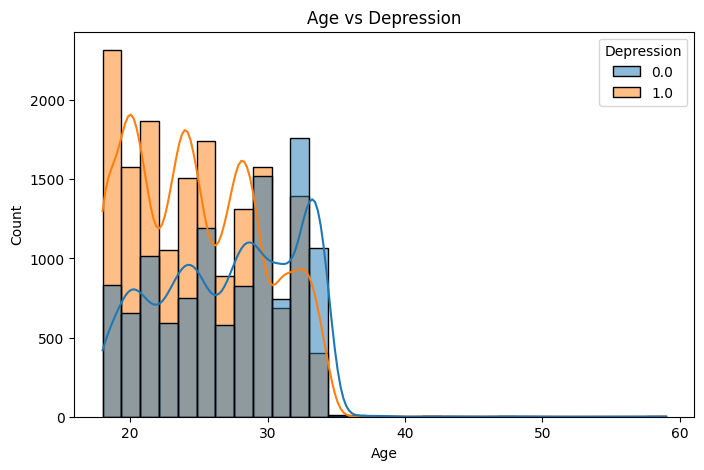

In [7]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='Depression', bins=30, kde=True)
plt.title("Age vs Depression")
plt.show()

Distribusi usia menunjukkan kelompok usia tertentu lebih rentan terhadap depresi.
→ Model non-linear seperti Random Forest cocok digunakan.

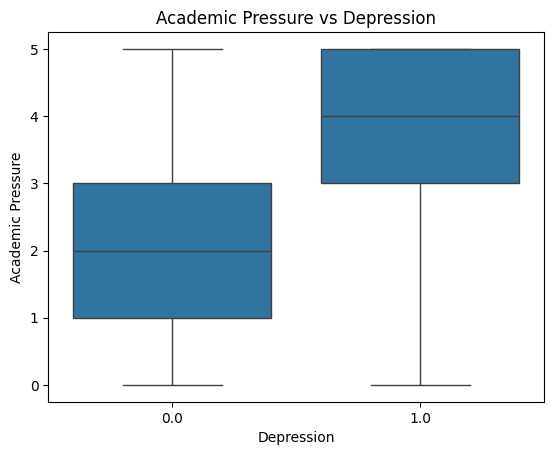

In [8]:
sns.boxplot(x='Depression', y='Academic Pressure', data=df)
plt.title("Academic Pressure vs Depression")
plt.show()

Mahasiswa dengan tekanan akademik tinggi cenderung memiliki tingkat depresi yang lebih tinggi.
→ Oleh karena itu, fitur Academic Pressure sangat penting dan tidak boleh dihapus.

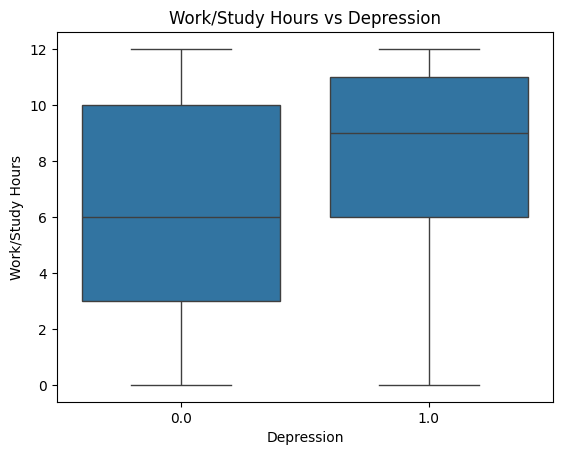

In [9]:
sns.boxplot(x='Depression', y='Work/Study Hours', data=df)
plt.title("Work/Study Hours vs Depression")
plt.show()

Durasi belajar/kerja yang berlebihan berkorelasi dengan peningkatan depresi.
→ Perlu dilakukan scaling karena distribusi tidak seimbang.

In [15]:
df_model = df.copy()

df_model = df_model.dropna(subset=['Depression'])

for col in df_model.select_dtypes(include=['float64', 'int64']).columns:
    df_model[col] = df_model[col].fillna(df_model[col].median())

for col in df_model.select_dtypes(include=['object']).columns:
    df_model[col] = df_model[col].fillna(df_model[col].mode()[0])

In [16]:
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].astype('category').cat.codes

In [17]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Depression', axis=1)
y = df_model['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. DIRECT MODELING (SEBELUM PREPROCESSING)

In [10]:
df_model = df.copy()

# encode kategori
for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = df_model[col].astype('category').cat.codes

In [11]:
from sklearn.model_selection import train_test_split

X = df_model.drop('Depression', axis=1)
y = df_model['Depression']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier()
}

In [18]:
from sklearn.metrics import accuracy_score

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test, pred)
    results[name] = acc
    print(name, "Accuracy:", acc)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Accuracy: 0.8314828080229226
Decision Tree Accuracy: 0.765580229226361
Random Forest Accuracy: 0.8357808022922636
SVM Accuracy: 0.5789756446991404
KNN Accuracy: 0.5327722063037249


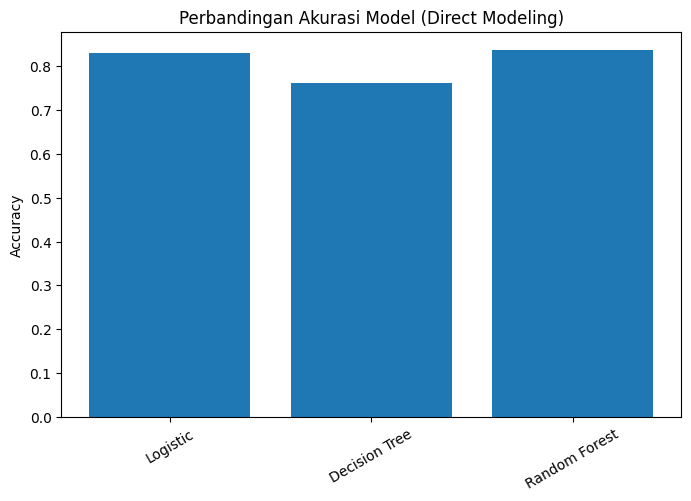

In [21]:
plt.figure(figsize=(8,5))
plt.bar(results_direct.keys(), results_direct.values())
plt.title("Perbandingan Akurasi Model (Direct Modeling)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

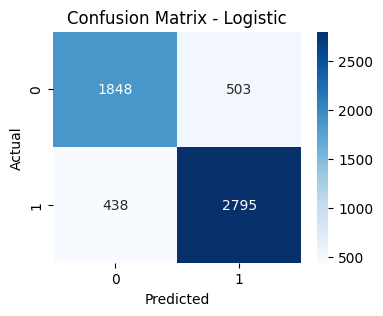

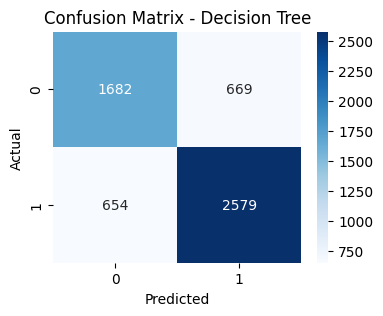

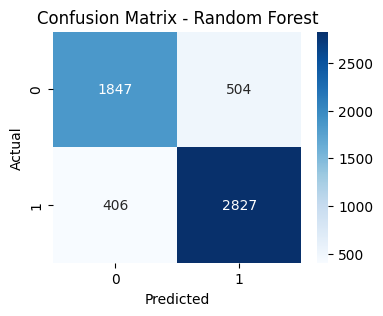

In [44]:
import seaborn as sns

for name, cm in conf_matrix_direct.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 3. MODELING DENGAN PREPROCESSING

In [60]:
df_clean = df.copy()


df_clean = df_clean.dropna(subset=['Depression'])


df_clean['Financial Stress'] = df_clean['Financial Stress'].fillna(df_clean['Financial Stress'].median())

df_clean['Family History of Mental Illness'] = df_clean['Family History of Mental Illness'].fillna(
    df_clean['Family History of Mental Illness'].mode()[0]
)

In [32]:
df_clean = pd.get_dummies(df_clean, drop_first=True)

In [33]:
from sklearn.preprocessing import StandardScaler

X = df_clean.drop('Depression', axis=1)
y = df_clean['Depression']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [35]:
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    print(name, "Accuracy:", accuracy_score(y_test, pred))

Logistic Accuracy: 0.8409742120343839
Decision Tree Accuracy: 0.7711318051575932
Random Forest Accuracy: 0.8356017191977078
SVM Accuracy: 0.8393624641833811
KNN Accuracy: 0.7260028653295129


In [54]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

results_clean = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, pred)
    results_clean[name] = acc

    print(f"{name}: {acc:.4f}")

Logistic: 0.8408
Decision Tree: 0.7620
Random Forest: 0.8261
SVM: 0.8376
KNN: 0.8146


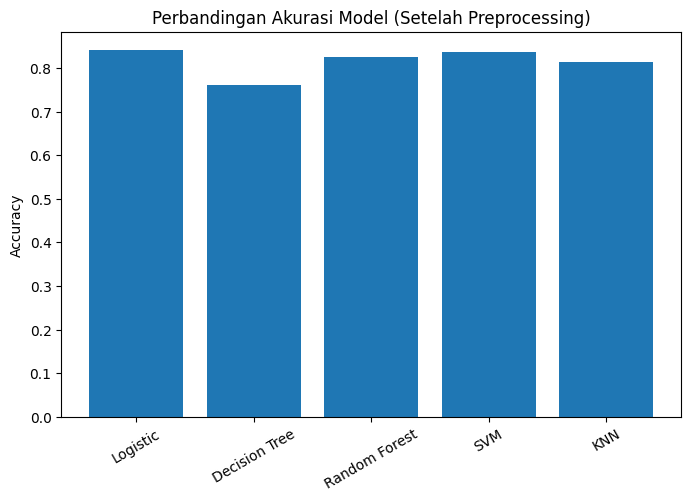

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(results_clean.keys(), results_clean.values())
plt.title("Perbandingan Akurasi Model (Setelah Preprocessing)")
plt.ylabel("Accuracy")
plt.xticks(rotation=30)
plt.show()

In [57]:
from sklearn.metrics import confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

conf_matrix_clean = {}

for name, model in models.items():

    pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    pipeline.fit(X_train, y_train)
    pred = pipeline.predict(X_test)

    cm = confusion_matrix(y_test, pred)
    conf_matrix_clean[name] = cm

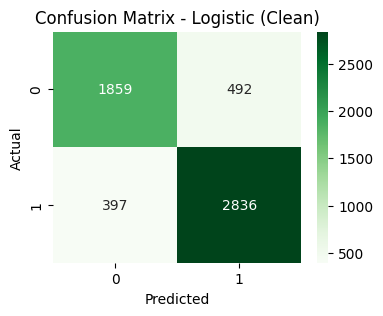

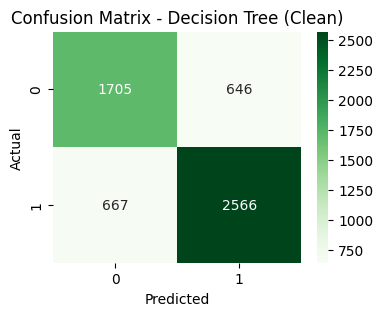

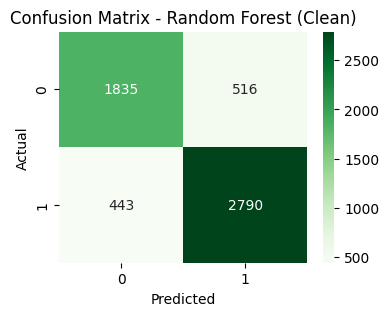

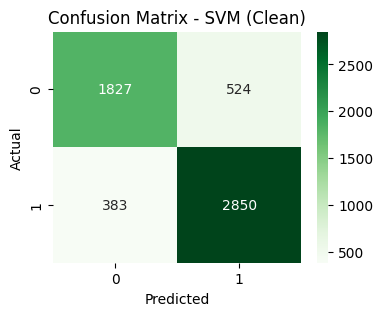

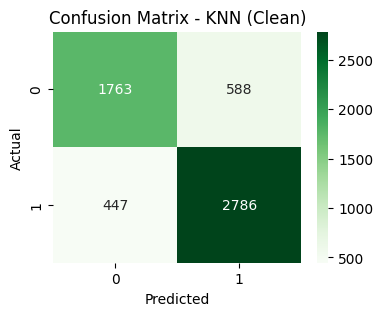

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

for name, cm in conf_matrix_clean.items():
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
    plt.title(f'Confusion Matrix - {name} (Clean)')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

## 4. FEATURE SELECTION

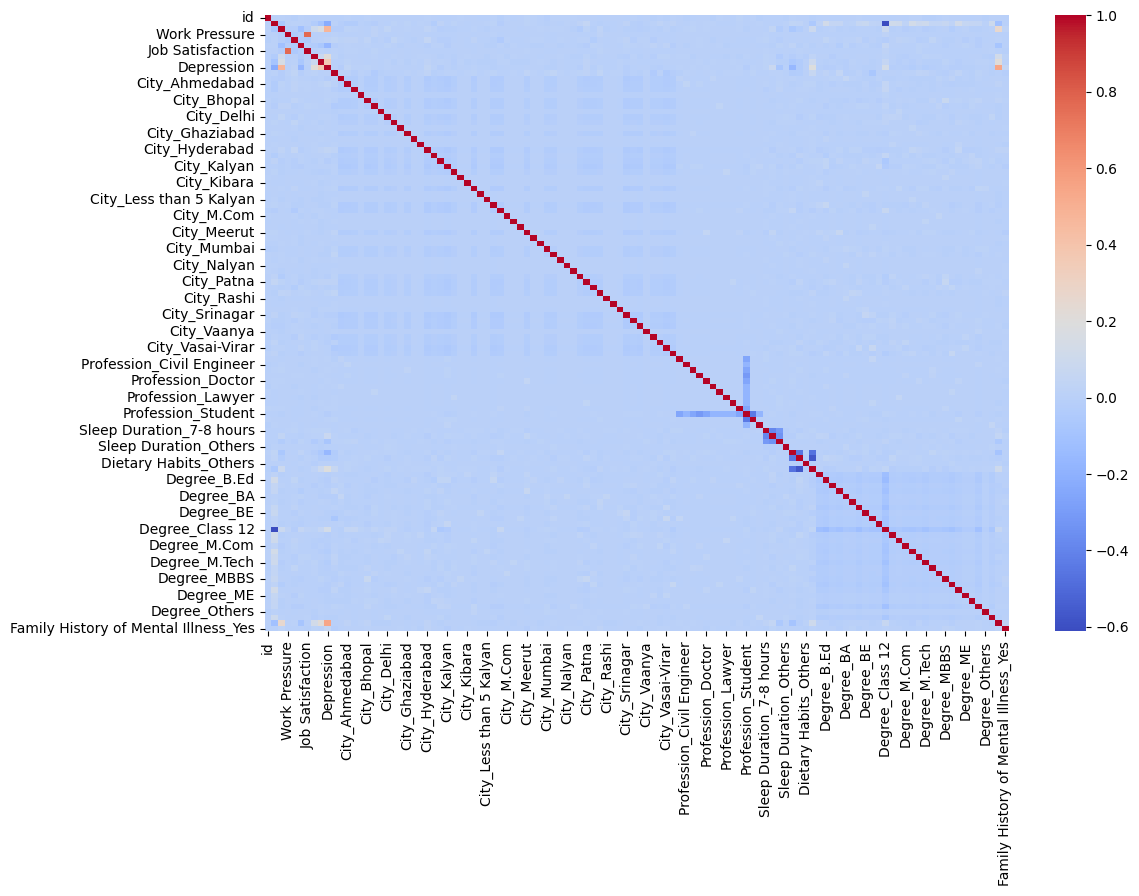

In [39]:
corr = df_clean.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [40]:
top_features = corr['Depression'].abs().sort_values(ascending=False)

selected_features = top_features.index[1:15]

X_selected = df_clean[selected_features]
y = df_clean['Depression']

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy setelah feature selection:", accuracy_score(y_test, pred))

Accuracy setelah feature selection: 0.8255730659025788


## 5. HYPERPARAMETER TUNING

In [42]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3, n_jobs=-1)

grid.fit(X_train, y_train)

GridSearchCV(cv=3, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [5, 10, None],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100]})

In [59]:
print("Best Params:", grid.best_params_)

best_model = grid.best_estimator_

pred = best_model.predict(X_test)

print("Final Accuracy:", accuracy_score(y_test, pred))

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 50}
Final Accuracy: 0.8372134670487106
